In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings("ignore")

# Configuración de estilo
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline

In [5]:
# Cargar el dataset
import os

df = pd.read_csv("incidencias.csv")

print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())

# Asegurarnos de que no hay nulos en los campos que nos importan
df = df.dropna(subset=["description", "categoria", "urgencia"])

Forma del dataset: (1000, 11)

Primeras filas:


,nombre,apellidos,nif,telefono,email,categoria,description,urgencia,fecha,direccion_persona,ubicacion_incidencia
0,Rosa,Núñez Rodríguez,45167429Y,931315752,rosa_nunez26@yahoo.es,Otros,Pintada en forma de rótulos obscenos en la par...,1,2026-01-01T15:52:55+01:00,"Calle Sierpe 106, 5ºA, 18004 Granada","37.176511, -3.588882 - Bajo la marquesina del ..."
1,Alberto,González García,59304412Q,983389471,alberto_gonzalez23@live.com,Limpieza,Hay papeles de caramelos y bolsas de plástico ...,1,2026-01-01T16:47:58+01:00,"Calle Elvira 66, 3ºB, 18014 Granada","37.180986, -3.589903 - Frente a la farmacia"
2,Javier,Marín López,21500031E,985590542,javier_marin33@live.com,Limpieza,El contenedor de reciclaje en Plazuela de Faja...,2,2026-01-01T20:58:51+01:00,"Calle Gonzalo Gallas 29, 3ºB, 18006 Granada","37.195520, -3.616094 - En la rotonda"
3,Josefa,Cortés Martínez,67375010Y,773400788,jcortes939@gmail.com,Limpieza,Hay basura acumulada hace 4 días en la calle D...,3,2026-01-01T21:26:04+01:00,"Calle Gonzalo Gallas 84, 4ºB, 18009 Granada","37.167973, -3.593403 - Frente a la farmacia"
4,Rocío,Navarro Guerrero,71422036K,761307077,rocionavarro762@gmail.com,Parques y Jardines,El cesped del parque de la Virgen del Carmen e...,1,2026-01-02T09:19:32+01:00,"Paseo de la Bomba 26, 3ºC, 18011 Granada","37.190636, -3.596631 - Junto al centro de salud"


In [6]:
# Definir las variables de entrada y la variable objetivo
X_text = df["description"].astype(str)
X_cat = df[
    ["categoria"]
].copy()  # Añade 'canal' a esta lista si lo vas a usar como variable

# La urgencia la tratamos como un número continuo de tipo float
y = df["urgencia"].astype(float)

# 1. Vectorización de Texto (TF-IDF)
tfidf = TfidfVectorizer(max_features=1000, stop_words="english", ngram_range=(1, 2))
X_text_tfidf = tfidf.fit_transform(X_text).toarray()

# 2. Codificación de Variables Categóricas (One-Hot Encoding)
X_cat_encoded_df = pd.get_dummies(X_cat, columns=["categoria"], drop_first=True)
expected_cat_cols = X_cat_encoded_df.columns  # Guardar las columnas esperadas
X_cat_encoded = X_cat_encoded_df.values

# 3. Concatenar todas las características en una sola matriz
X = np.hstack((X_text_tfidf, X_cat_encoded))

# Dividir el conjunto de datos en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

Dimensiones de entrenamiento: (800, 1005)
Dimensiones de prueba: (200, 1005)


In [7]:
# Inicializar y entrenar el modelo de regresión
# Puedes probar también con GradientBoostingRegressor()
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = rf_regressor.predict(X_test)

In [8]:
# Limitamos las predicciones para que no se salgan del rango lógico (1.0 - 5.0)
y_pred_clipped = np.clip(y_pred, 1.0, 5.0)

# 1. Valor exacto con 2 decimales
y_pred_decimal = np.round(y_pred_clipped, 2)

# 2. Valor redondeado para la clasificación (Categoría de 1 a 5)
y_pred_rounded = np.round(y_pred_clipped).astype(int)

# --- Evaluación de Regresión ---
print("--- MÉTRICAS DE REGRESIÓN ---")
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred_decimal):.4f}")
print(f"Error Absoluto Medio (MAE): {mean_absolute_error(y_test, y_pred_decimal):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_decimal):.4f}")

# --- Evaluación del Redondeo vs Realidad (como Clasificación) ---
from sklearn.metrics import accuracy_score, classification_report

print("\n--- MÉTRICAS DE CLASIFICACIÓN (Urgencia Redondeada) ---")
print(
    f"Accuracy Exacta (predicción redondeada == real): {accuracy_score(y_test, y_pred_rounded):.4f}"
)
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_rounded))

--- MÉTRICAS DE REGRESIÓN ---
Error Cuadrático Medio (MSE): 0.6579
Error Absoluto Medio (MAE): 0.5647
R2 Score: 0.6765

--- MÉTRICAS DE CLASIFICACIÓN (Urgencia Redondeada) ---
Accuracy Exacta (predicción redondeada == real): 0.6250

Reporte de Clasificación:
               precision    recall  f1-score   support

         1.0       0.93      0.52      0.67        48
         2.0       0.60      0.78      0.67        40
         3.0       0.52      0.90      0.66        41
         4.0       0.53      0.57      0.55        35
         5.0       1.00      0.33      0.50        36

    accuracy                           0.62       200
   macro avg       0.71      0.62      0.61       200
weighted avg       0.72      0.62      0.62       200



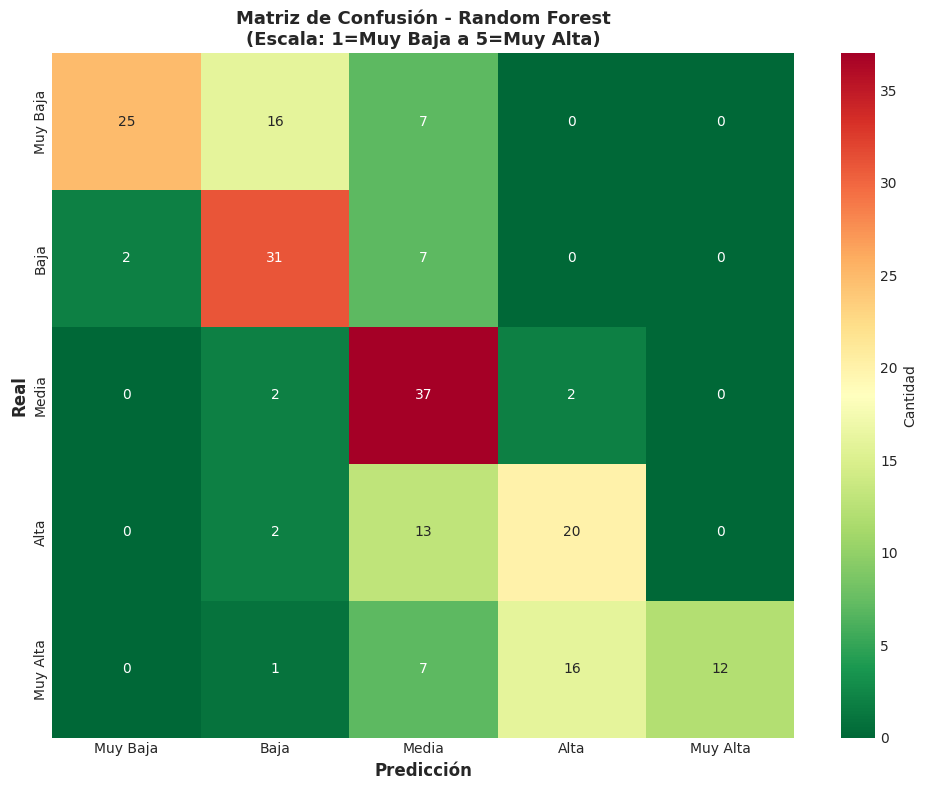

In [12]:
# Calcular y visualizar matriz de confusión
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred_rounded, labels=[1, 2, 3, 4, 5])

# Visualizar matriz de confusión con etiquetas de urgencia
urgency_labels_cm = ["Muy Baja", "Baja", "Media", "Alta", "Muy Alta"]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdYlGn_r",
    ax=ax,
    cbar=True,
    xticklabels=urgency_labels_cm,
    yticklabels=urgency_labels_cm,
    cbar_kws={"label": "Cantidad"},
)
ax.set_xlabel("Predicción", fontsize=12, fontweight="bold")
ax.set_ylabel("Real", fontsize=12, fontweight="bold")
ax.set_title(
    "Matriz de Confusión - Random Forest\n(Escala: 1=Muy Baja a 5=Muy Alta)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [13]:
def predecir_urgencia(descripcion, categoria):
    """
    Toma una descripción y su categoría y predice el nivel de urgencia.
    Retorna el valor con dos decimales y el nivel de clasificación (1-5).
    """
    # Validar que la categoría existe en el entrenamiento
    categorias_validas = df["categoria"].unique()
    if categoria not in categorias_validas:
        raise ValueError(
            f"Categoría '{categoria}' no válida. Opciones: {', '.join(categorias_validas)}"
        )

    # 1. Transformar texto
    text_tf = tfidf.transform([descripcion]).toarray()

    # 2. Transformar categoría a One-Hot respetando las columnas del entrenamiento
    cat_df = pd.DataFrame({"categoria": [categoria]})
    cat_encoded_full = pd.get_dummies(cat_df, columns=["categoria"], drop_first=True)

    # Asegurar que tiene exactamente las mismas columnas categóricas que en entrenamiento
    cat_encoded = cat_encoded_full.reindex(
        columns=expected_cat_cols, fill_value=0
    ).values

    # 3. Concatenar
    X_new = np.hstack((text_tf, cat_encoded))

    # 4. Predecir
    pred_raw = rf_regressor.predict(X_new)[0]

    # 5. Limitar y Redondear
    pred_clipped = np.clip(pred_raw, 1.0, 5.0)
    urgencia_exacta = round(pred_clipped, 2)
    urgencia_clase = int(round(pred_clipped))

    return urgencia_exacta, urgencia_clase


# --- PRUEBA DEL MODELO ---
test_cases = [
    {
        "desc": "Un envase de productos químicos peligrosos ha sido abandonado en un parque, a 50 metros del colegio.",
        "cat": "Limpieza",
    },
    {
        "desc": "Pintada en forma de rótulos obscenos en la pared de mi casa.",
        "cat": "Otros",
    },
]

print("=" * 60)
print("PRUEBAS DE INFERENCIA EN EL AYUNTAMIENTO")
print("=" * 60)

for case in test_cases:
    valor_exacto, nivel = predecir_urgencia(case["desc"], case["cat"])
    print(f"Descripción: {case['desc']}")
    print(f"Categoría: {case['cat']}")
    print(f"Urgencia Calculada (Interna): {valor_exacto} / 5.0")
    print(f"Nivel de Urgencia Final Asignado: {nivel}\n")

PRUEBAS DE INFERENCIA EN EL AYUNTAMIENTO
Descripción: Un envase de productos químicos peligrosos ha sido abandonado en un parque, a 50 metros del colegio.
Categoría: Limpieza
Urgencia Calculada (Interna): 4.65 / 5.0
Nivel de Urgencia Final Asignado: 5

Descripción: Pintada en forma de rótulos obscenos en la pared de mi casa.
Categoría: Otros
Urgencia Calculada (Interna): 3.02 / 5.0
Nivel de Urgencia Final Asignado: 3

